In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import PowerTransformer, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

import pickle

import random
seed = 42
random.seed(seed)

In [2]:
df = pd.read_csv('forestfires.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [4]:
X = df.drop('area', axis=1)
y = df['area']

In [5]:
X.columns

Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain'],
      dtype='object')

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3,random_state=seed)
X_test, X_dev, y_test, y_dev = train_test_split(X_test,y_test,test_size=.5,random_state=seed)

selected_features = [
    'X', 'Y', 'month',
    'FFMC', 'DMC', 'DC', 'ISI',
    'temp', 'RH','wind', 'rain'
    ]

X_train = X_train[selected_features]
X_test = X_test[selected_features]
X_dev = X_dev[selected_features]

In [7]:
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)
print('X_dev shape', X_dev.shape)
print('y_dev shape', y_dev.shape)

X_train shape (361, 11)
X_test shape (78, 11)
y_train shape (361,)
y_test shape (78,)
X_dev shape (78, 11)
y_dev shape (78,)


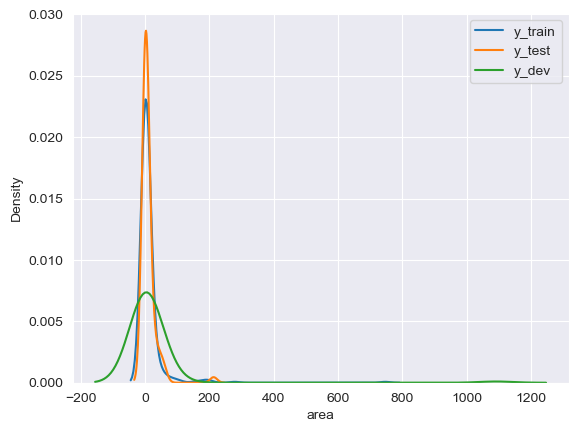

In [8]:
sns.kdeplot(y_train,label='y_train')
sns.kdeplot(y_test,label='y_test')
sns.kdeplot(y_dev,label='y_dev')
plt.legend()
plt.show()

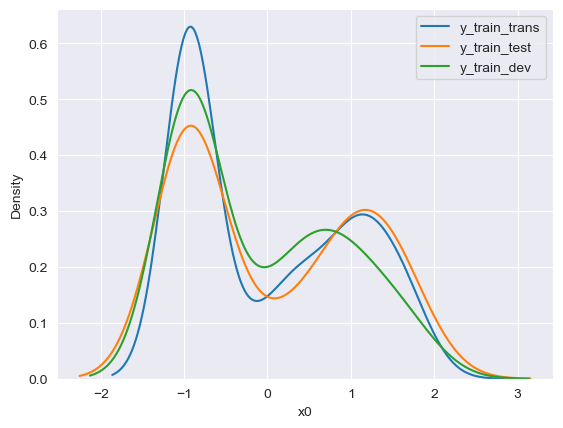

In [9]:
pt = PowerTransformer(method='yeo-johnson').set_output(transform='pandas')
y_train_trans = pt.fit_transform(y_train.values.reshape(-1, 1))
y_test_trans = pt.transform(y_test.values.reshape(-1, 1))
y_dev_trans = pt.transform(y_dev.values.reshape(-1, 1))

plt.figure()
sns.kdeplot(y_train_trans.iloc[:,0],label='y_train_trans')
sns.kdeplot(y_test_trans.iloc[:,0],label='y_train_test')
sns.kdeplot(y_dev_trans.iloc[:,0],label='y_train_dev')
plt.legend()
plt.show()

In [10]:
X_train.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,361.000000,361.00000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000
mean,4.731302,4.34626,90.554017,112.105263,545.957064,8.750139,18.863158,44.745152,3.966759,0.024377
std,2.289430,1.20844,5.919623,66.049523,250.585297,3.911409,5.767293,16.560038,1.781651,0.343938
min,1.000000,2.00000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.900000,0.000000
25%,3.000000,4.00000,90.200000,70.800000,430.800000,6.500000,15.500000,33.000000,2.700000,0.000000
50%,4.000000,4.00000,91.600000,108.400000,664.200000,8.400000,19.100000,42.000000,4.000000,0.000000
75%,7.000000,5.00000,92.900000,141.300000,714.300000,10.600000,22.600000,54.000000,5.400000,0.000000
max,9.000000,9.00000,96.200000,291.300000,860.600000,22.700000,33.300000,100.000000,9.400000,6.400000


In [11]:
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

if 'month' in X_train.columns:
    X_train.month = X_train.month.map(month_map)
    X_test.month = X_test.month.map(month_map)
    X_dev.month = X_dev.month.map(month_map)

In [12]:
ss = StandardScaler().set_output(transform='pandas')
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)
X_dev_scaled = ss.transform(X_dev)

In [13]:
X_train_scaled.describe()

,X,Y,month,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,3.610000e+02,3.610000e+02,3.610000e+02,3.610000e+02,3.610000e+02,361.000000,3.610000e+02,3.610000e+02,3.610000e+02,3.610000e+02,3.610000e+02
mean,-4.428590e-17,-1.968262e-17,-1.476197e-16,-7.504000e-17,-2.829377e-17,0.000000,3.936525e-17,-3.210728e-16,1.254767e-16,1.377784e-16,-1.476197e-17
std,1.001388e+00,1.001388e+00,1.001388e+00,1.001388e+00,1.001388e+00,1.001388,1.001388e+00,1.001388e+00,1.001388e+00,1.001388e+00,1.001388e+00
min,-1.632057e+00,-1.944257e+00,-2.838113e+00,-1.215512e+01,-1.682969e+00,-2.150181,-2.240186e+00,-2.893261e+00,-1.798694e+00,-1.723691e+00,-7.097384e-02
25%,-7.572648e-01,-2.869328e-01,-1.986314e-01,-5.988692e-02,-6.262360e-01,-0.460190,-5.760742e-01,-5.839526e-01,-7.102311e-01,-7.119896e-01,-7.097384e-02
50%,-3.198687e-01,-2.869328e-01,2.412823e-01,1.769429e-01,-5.617612e-02,0.472522,-8.964148e-02,4.112342e-02,-1.659998e-01,1.868331e-02,-7.097384e-02
75%,9.923199e-01,5.417291e-01,6.811959e-01,3.968563e-01,4.426263e-01,0.672731,4.735964e-01,6.488362e-01,5.596420e-01,8.055619e-01,-7.097384e-02
max,1.867112e+00,3.856377e+00,2.000937e+00,9.550979e-01,2.716802e+00,1.257375,3.571405e+00,2.506701e+00,3.341269e+00,3.053786e+00,1.856288e+01


In [14]:
random.randint(0, 100,)

81

In [15]:
def get_zero_threshold(y, y_pred,q=.8,range=None):
    q = y < y.quantile(q)
    if range is None:
        range_end = y_pred[y == 0].max()
        thresholds = np.arange(0.01,range_end,0.01)
    else:
        thresholds = range
    maes = []
    for t in thresholds:
        y_pred_copy = y_pred.copy()
        y_pred_copy[y_pred < t] = 0
        mae = mean_absolute_error(y[q],y_pred_copy[q])
        maes.append(mae)
    threshold = thresholds[np.argmin(maes)]
    return threshold , maes, thresholds

def plot_threshold_mae(threshold, maes, thresholds):
    line = sns.lineplot(x=thresholds,y=maes)
    line.set_xlabel('Threshold')
    line.set_ylabel('MAE')
    sns.scatterplot(x=[threshold],y=[maes[np.argmin(maes)]],color='red',label='Best Threshold')
    plt.show()

In [16]:
def get_coef(y_train, y_train_pred,q=.8,range=None):
    maes = []
    q = y_train < y_train.quantile(q)
    if range is None:
        prob_coef = (y_train[q]/y_train_pred[q]).values.mean(where=y_train_pred[q]>0)
        coef_range = np.arange(prob_coef-1,prob_coef+1,.1)
    else:
        coef_range = range

    for c in coef_range:
        mae = mean_absolute_error(y_train,y_train_pred*c)
        maes.append(mae)
    coef = coef_range[np.argmin(maes)]
    return coef, maes, coef_range

def plot_coef_mae(coef, maes, coef_range):
    coef = coef_range[np.argmin(maes)]
    sns.lineplot(x=coef_range,y=maes)
    sns.scatterplot(x=[coef],y=[maes[np.argmin(maes)]],color='red',label='Best coef')
    plt.xlabel('coef_range')
    plt.ylabel('MAE')
    plt.title('Coef Range vs MAE')
    plt.show()

In [17]:
def train_model(model,params,n_trials=50,q=0.8):

    def objective(trial):
        params(trial)
        model.set_params(**trial.params)
        score = cross_val_score(model, X_train, y_train_trans, cv=5, scoring='neg_mean_absolute_error').mean()
        return score

    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials)

    model.set_params(**study.best_params)
    model.fit(X_train_scaled,y_train_trans)
    return model, study

def initial_resutl(model,q=.8):
    y_train_pred = pt.inverse_transform(model.predict(X_train_scaled).reshape(-1,1)).flatten()

    train_MAE = mean_absolute_error(y_train, y_train_pred)
    train_MSE = mean_squared_error(y_train, y_train_pred)
    train_RMSE = np.sqrt(train_MSE)

    q = y_train < y_train.quantile(q)

    plt.figure(figsize=(10,10))
    sct = sns.scatterplot(x=y_train[q],y=y_train_pred[q])
    plt.xlabel('y_train')
    plt.ylabel('y_train_pred')
    plt.title('initial')
    sct.set_aspect('equal')
    plt.show()

    print('Train MAE: ', train_MAE)
    print('Train MSE: ', train_MSE)
    print('Train RMSE: ', train_RMSE)

def visualization(model, study):

    plot_optimization_history(study).show()
    plot_parallel_coordinate(study).show()
    plot_param_importances(study).show()

    feature_importances = permutation_importance(model, X_train_scaled, y_train_trans, n_repeats=10, random_state=seed)
    sorted_idx = feature_importances.importances_mean.argsort()[::-1]
    sns.barplot(x=feature_importances.importances_mean[sorted_idx], y=X_train_scaled.columns[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.show()

## Model Training


### XGBRegressor

In [18]:
def xgb_params(trial):
    trial.suggest_int('max_depth', 3, 12)
    trial.suggest_int('max_leaves', 8, 256)
    trial.suggest_int('min_child_weight', 1, 10)
    trial.suggest_float('gamma', 0.0, 1.0)
    trial.suggest_float('subsample', 0.6, 1.0)
    trial.suggest_float('colsample_bytree', 0.6, 1.0)
    trial.suggest_float('colsample_bylevel', 0.6, 1.0)
    trial.suggest_float('colsample_bynode', 0.6, 1.0)
    trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    trial.suggest_int('n_estimators', 50, 1000)
    trial.suggest_float('reg_alpha', 0.0, 1.0)
    trial.suggest_float('reg_lambda', 0.0, 1.0)
    trial.suggest_int('max_delta_step', 0, 10)
    trial.suggest_int('max_bin', 64, 1024, step=64)

xgb = XGBRegressor(eval_metric='mae',random_state=seed, n_jobs=-1)

xgb_model, xgb_study = train_model(xgb,xgb_params,n_trials=30)

[I 2025-05-16 06:07:36,232] A new study created in memory with name: no-name-31e9729b-8c86-4724-ae1f-9c7342592a21
[I 2025-05-16 06:07:37,032] Trial 0 finished with value: -0.9329497644018113 and parameters: {'max_depth': 6, 'max_leaves': 244, 'min_child_weight': 8, 'gamma': 0.5986584841970366, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'colsample_bynode': 0.9464704583099741, 'learning_rate': 0.07725378389307355, 'n_estimators': 723, 'reg_alpha': 0.020584494295802447, 'reg_lambda': 0.9699098521619943, 'max_delta_step': 9, 'max_bin': 256}. Best is trial 0 with value: -0.9329497644018113.
[I 2025-05-16 06:07:37,542] Trial 1 finished with value: -0.9179186904545382 and parameters: {'max_depth': 4, 'max_leaves': 53, 'min_child_weight': 4, 'gamma': 0.5247564316322378, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'colsample_bylevel': 0.8447411578889518, 'colsample_bynode': 0.6557975442608167, 'le

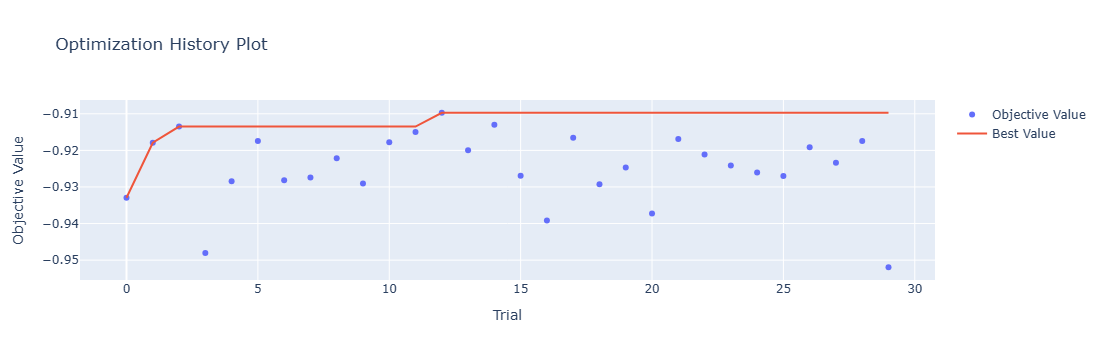

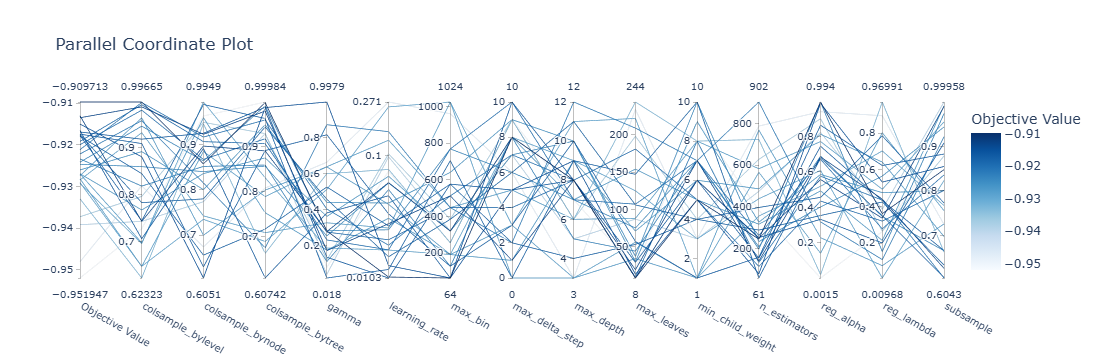

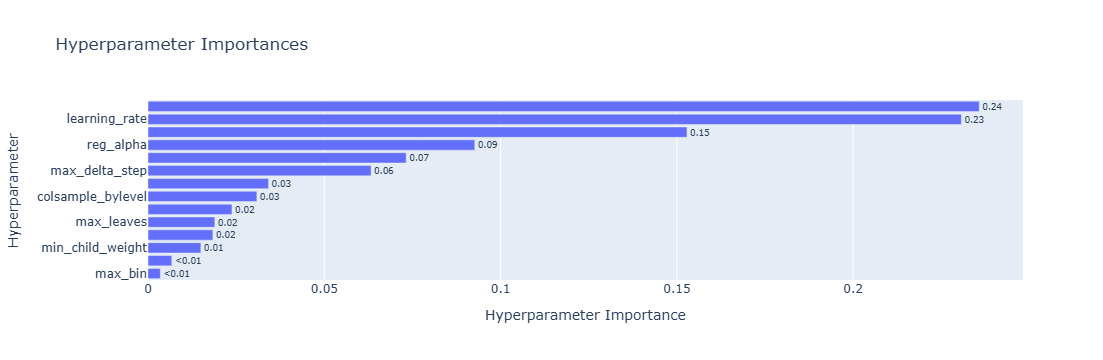

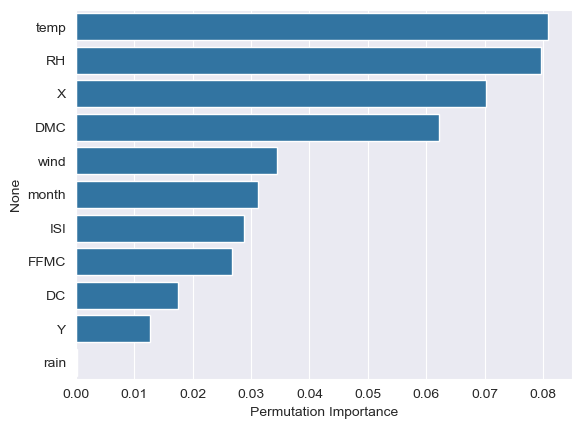

Initial_result


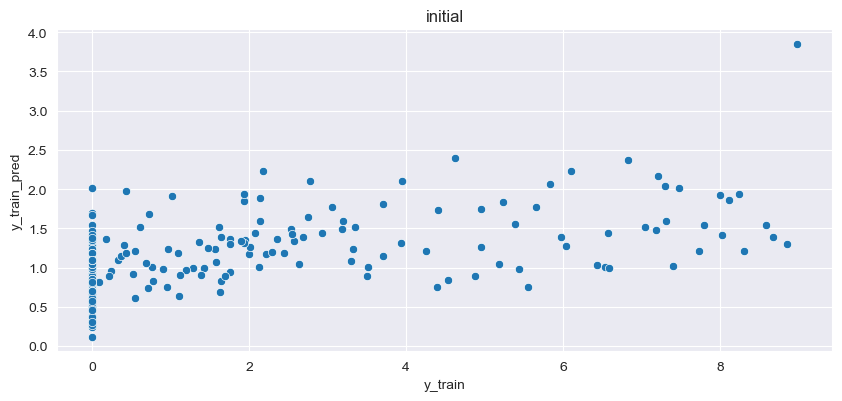

Train MAE:  11.593825879955556
Train MSE:  2454.345574797159
Train RMSE:  49.54135216964873


In [19]:
visualization(xgb_model, xgb_study)
print('Initial_result')
initial_resutl(xgb_model)

In [20]:
y_dev_pred = pt.inverse_transform(xgb_model.predict(X_dev_scaled).reshape(-1,1)).flatten()

dev_MAE = mean_absolute_error(y_dev, y_dev_pred)
dev_MSE = mean_squared_error(y_dev, y_dev_pred)
dev_RMSE = np.sqrt(dev_MSE)

print('dev MAE: ', dev_MAE)
print('dev MSE: ', dev_MSE)
print('dev RMSE: ', dev_RMSE)

dev MAE:  19.80943778948906
dev MSE:  15489.987634424539
dev RMSE:  124.45877885639301


### Support Vector Regressor

In [21]:
def svr_params(trial):
    trial.suggest_float('C', 1e-3, 1e3, log=True)
    trial.suggest_float('epsilon', 1e-4, 1, log=True)
    # trial.suggest_float('gamma', 1e-4, 10, log=True)

svr= SVR(kernel='linear')

svr_model, svr_study = train_model(svr,svr_params,n_trials=30)

[I 2025-05-16 06:07:54,872] A new study created in memory with name: no-name-80d04540-ac03-4295-840d-9101e86077fa
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape o

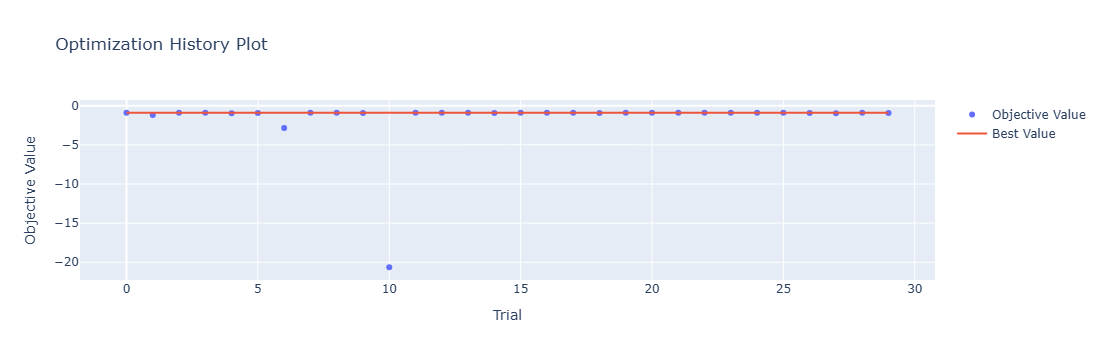

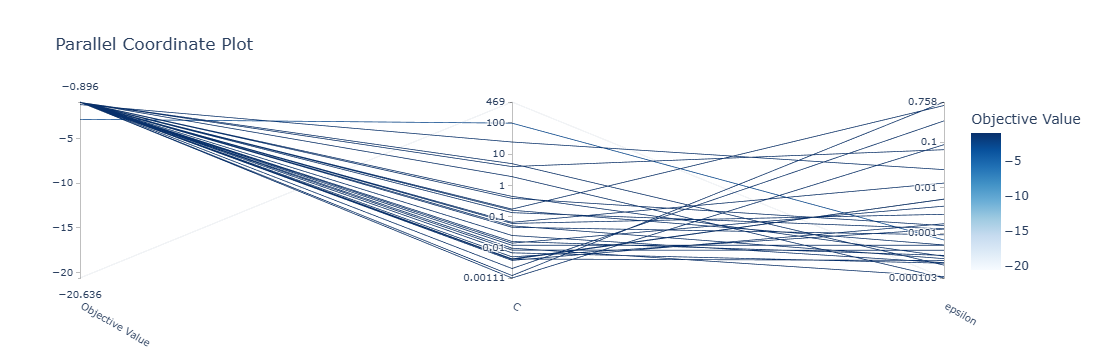

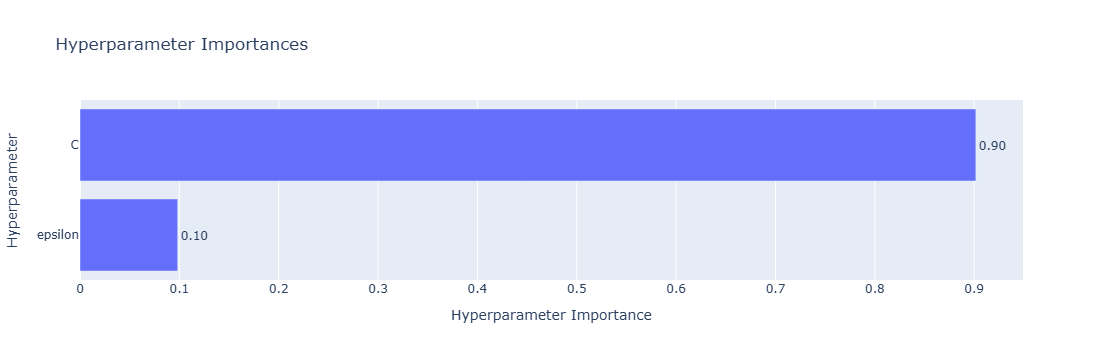

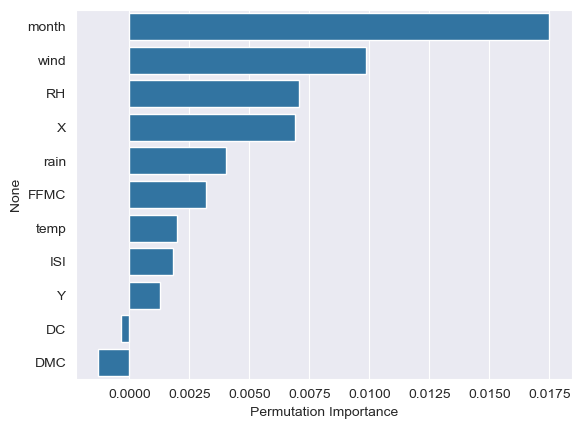

Initial_result


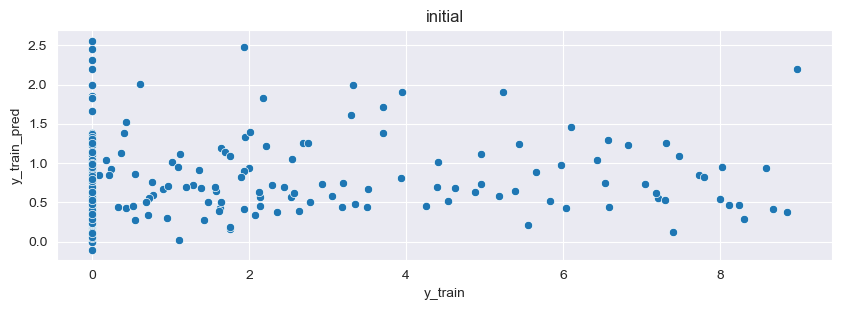

Train MAE:  11.828970270876367
Train MSE:  2471.1324786942882
Train RMSE:  49.71048660689501


In [22]:
visualization(svr_model, svr_study)
print('Initial_result')
initial_resutl(svr_model)

In [23]:
y_dev_pred = pt.inverse_transform(svr_model.predict(X_dev_scaled).reshape(-1,1)).flatten()

dev_MAE = mean_absolute_error(y_dev, y_dev_pred)
dev_MSE = mean_squared_error(y_dev, y_dev_pred)
dev_RMSE = np.sqrt(dev_MSE)

print('dev MAE: ', dev_MAE)
print('dev MSE: ', dev_MSE)
print('dev RMSE: ', dev_RMSE)

dev MAE:  19.74383687460905
dev MSE:  15509.552794248653
dev RMSE:  124.53735501546777


### Random Foerst Regressor

In [24]:
def rfr_params(trial):
    trial.suggest_int('n_estimators', 50, 1000)
    trial.suggest_int('max_depth', 3, 20)
    trial.suggest_int('min_samples_split', 2, 20)
    trial.suggest_int('min_samples_leaf', 1, 20)
    trial.suggest_float('max_features', 0.1, 1.0)
    trial.suggest_float('max_samples', 0.6, 1.0)
    trial.suggest_float('min_impurity_decrease', 0.0, 0.1)
    trial.suggest_float('ccp_alpha', 0.0, 0.1)


rfr = RandomForestRegressor(bootstrap=True,random_state=seed)

rfr_model, rfr_study = train_model(rfr,rfr_params,n_trials=30)

[I 2025-05-16 06:27:16,051] A new study created in memory with name: no-name-bcda8e5a-ee29-4007-9d97-b5a3c40cb8bf
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

C:

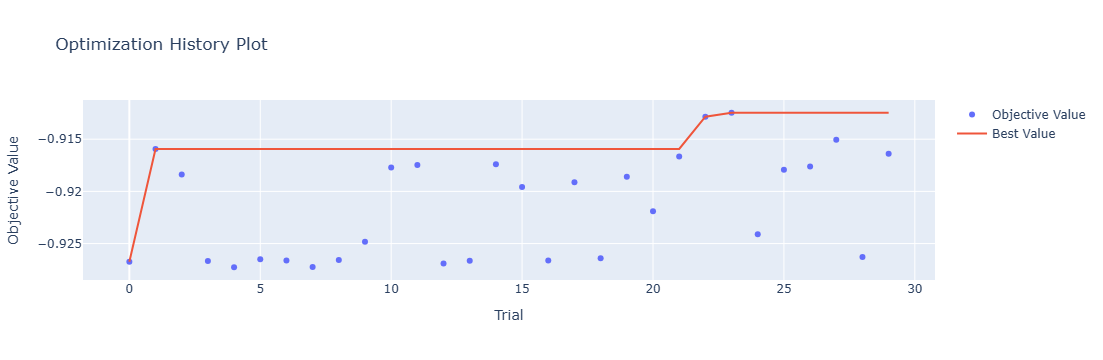

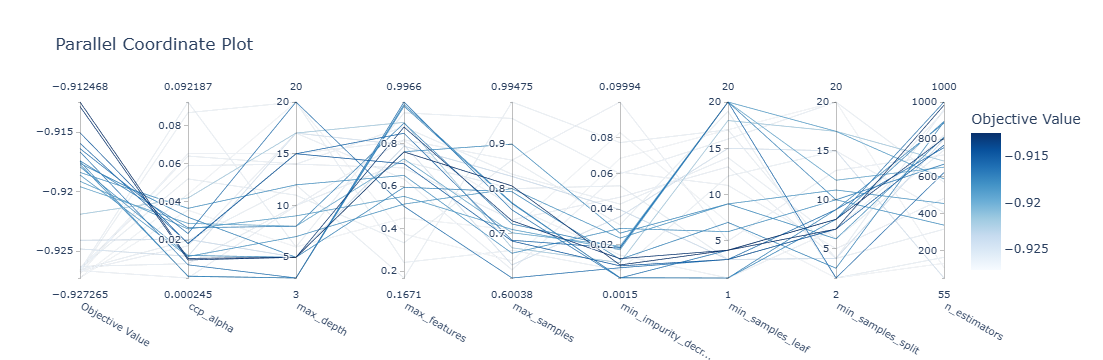

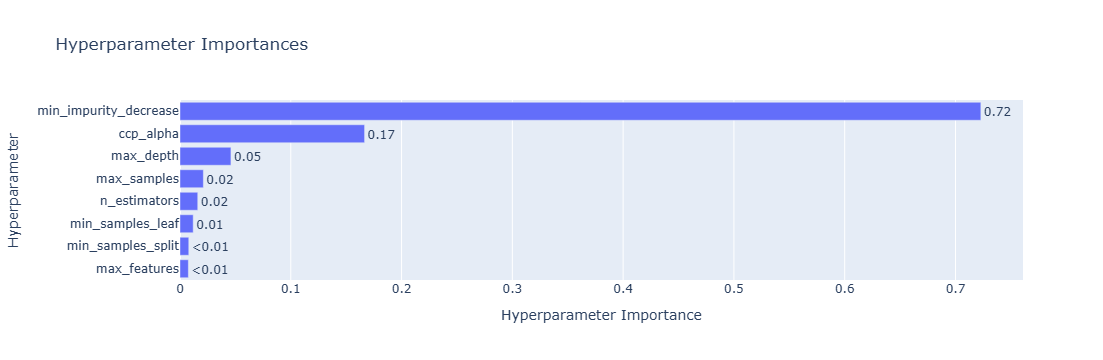

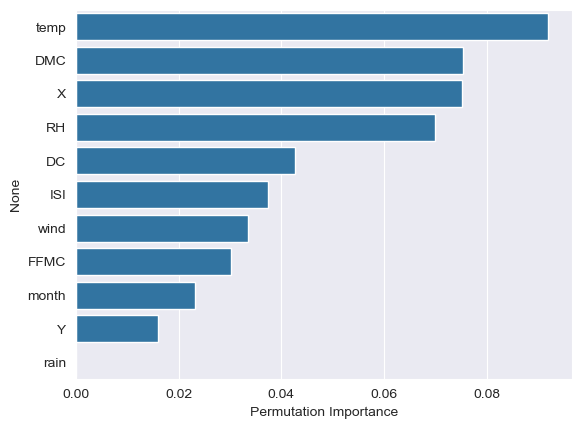

Initial_result


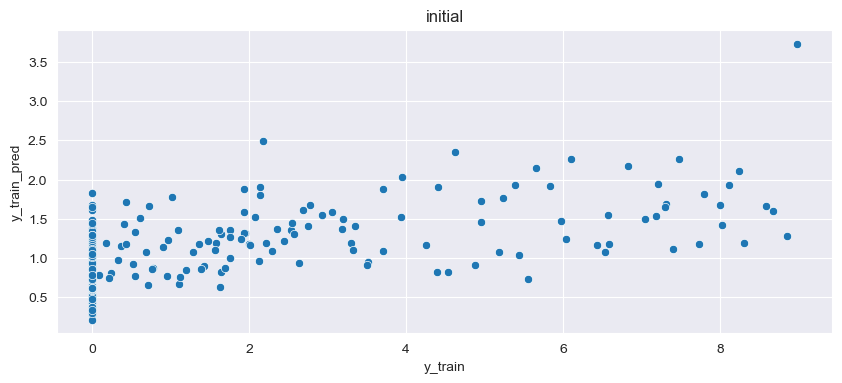

Train MAE:  11.597964896564804
Train MSE:  2453.2837061938612
Train RMSE:  49.53063401768507


In [25]:
visualization(rfr_model, rfr_study)
print('Initial_result')
initial_resutl(rfr_model)

In [26]:
y_dev_pred = pt.inverse_transform(rfr_model.predict(X_dev_scaled).reshape(-1,1)).flatten()

dev_MAE = mean_absolute_error(y_dev, y_dev_pred)
dev_MSE = mean_squared_error(y_dev, y_dev_pred)
dev_RMSE = np.sqrt(dev_MSE)

print('dev MAE: ', dev_MAE)
print('dev MSE: ', dev_MSE)
print('dev RMSE: ', dev_RMSE)

dev MAE:  19.79747304324668
dev MSE:  15493.342294493454
dev RMSE:  124.47225511933755


### ElasticNet

In [27]:
def en_params(trial):
    trial.suggest_float('alpha', 1e-4, 1.0, log=True)
    trial.suggest_float('l1_ratio', 0.0, 1.0)
    trial.suggest_categorical('fit_intercept', [True, False])
    trial.suggest_int('max_iter', 100, 5000)
    trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    trial.suggest_categorical('selection', ['cyclic', 'random'])

en = ElasticNet(random_state=seed)

en_model, en_study = train_model(en,en_params,n_trials=30)

[I 2025-05-16 06:29:09,450] A new study created in memory with name: no-name-ef6abc07-a0d4-4870-b75c-5dd6f42c6869
[I 2025-05-16 06:29:09,489] Trial 0 finished with value: -0.9330203944664767 and parameters: {'alpha': 0.003148911647956862, 'l1_ratio': 0.9507143064099162, 'fit_intercept': True, 'max_iter': 864, 'tol': 2.9375384576328295e-05, 'selection': 'random'}. Best is trial 0 with value: -0.9330203944664767.
[I 2025-05-16 06:29:09,520] Trial 1 finished with value: -0.9204839385253951 and parameters: {'alpha': 0.02537815508265665, 'l1_ratio': 0.7080725777960455, 'fit_intercept': False, 'max_iter': 4179, 'tol': 4.335281794951564e-05, 'selection': 'random'}. Best is trial 1 with value: -0.9204839385253951.
[I 2025-05-16 06:29:09,546] Trial 2 finished with value: -0.9370538448884508 and parameters: {'alpha': 0.0016480446427978971, 'l1_ratio': 0.5247564316322378, 'fit_intercept': True, 'max_iter': 3098, 'tol': 2.621087878265438e-05, 'selection': 'random'}. Best is trial 1 with value: -0.

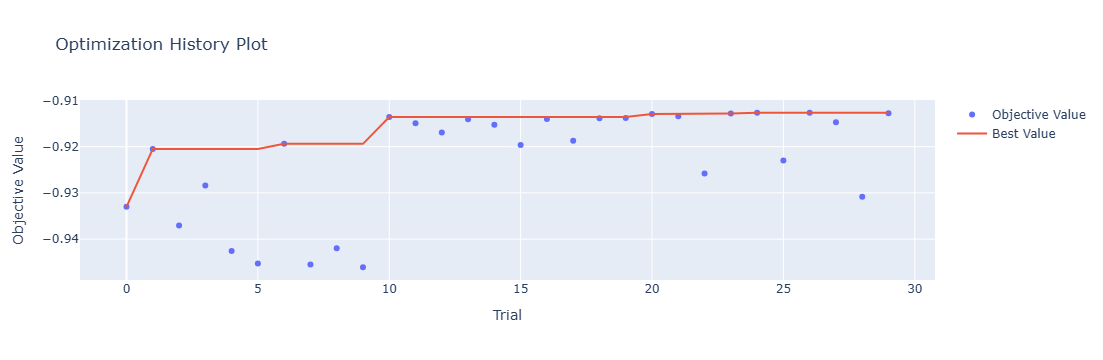

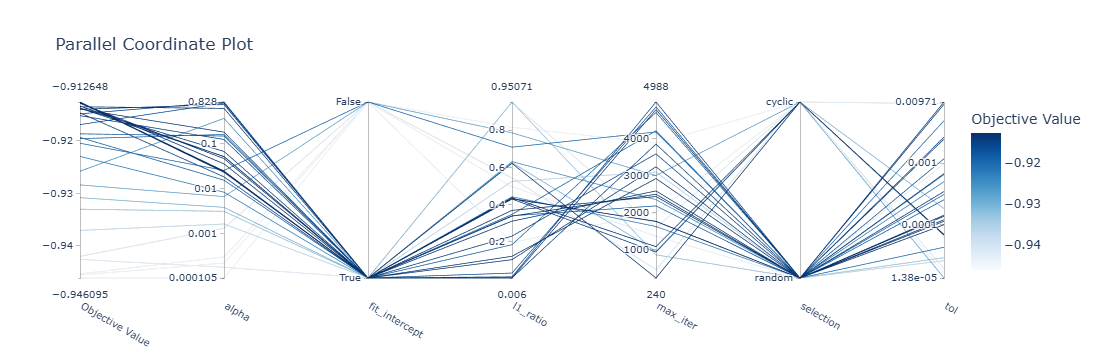

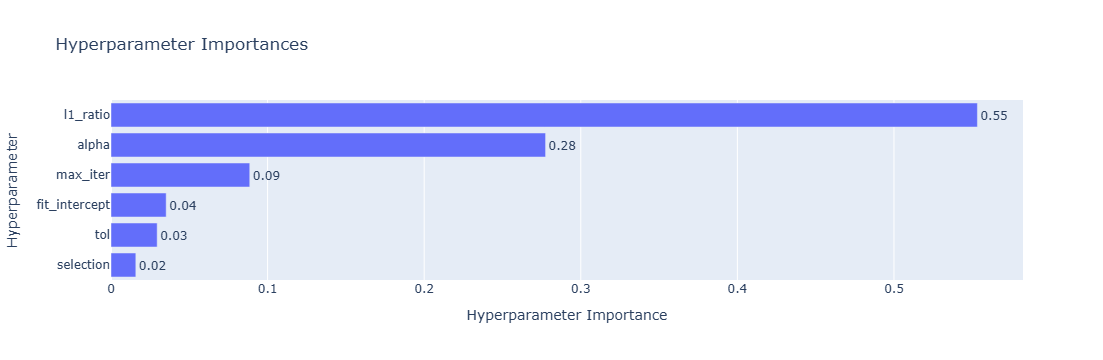

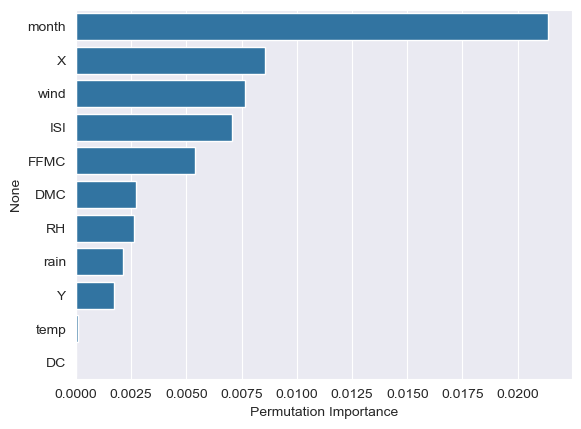

Initial_result


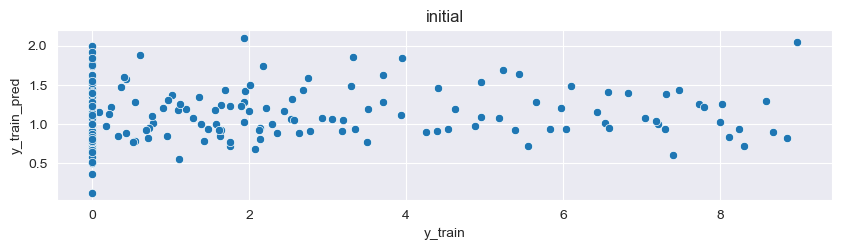

Train MAE:  11.877935647635049
Train MSE:  2463.709310428343
Train RMSE:  49.63576644344623


In [28]:
visualization(en_model, en_study)
print('Initial_result')
initial_resutl(en_model)

In [29]:
y_dev_pred = pt.inverse_transform(en_model.predict(X_dev_scaled).reshape(-1,1)).flatten()

dev_MAE = mean_absolute_error(y_dev, y_dev_pred)
dev_MSE = mean_squared_error(y_dev, y_dev_pred)
dev_RMSE = np.sqrt(dev_MSE)

print('dev MAE: ', dev_MAE)
print('dev MSE: ', dev_MSE)
print('dev RMSE: ', dev_RMSE)

dev MAE:  19.781496226680908
dev MSE:  15492.108707180865
dev RMSE:  124.46729975050019


### LightGBM Regressor

In [30]:
def lgbm_params(trial):
    trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss'])
    trial.suggest_int('num_leaves', 10, 1000)
    trial.suggest_int('max_depth', 3, 15)
    trial.suggest_float('learning_rate', 1e-4, 0.1, log=True)
    trial.suggest_int('n_estimators', 50, 1000)
    trial.suggest_int('min_child_samples', 5, 100)
    trial.suggest_float('subsample', 0.5, 1.0)
    trial.suggest_float('colsample_bytree', 0.5, 1.0)
    trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True)
    trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True)

lgbm = LGBMRegressor(objective='regression',
                     metric='mae',
                     n_jobs=-1,
                     random_state=seed,
                     verbose=-1)

lgbm_model, lgbm_study = train_model(lgbm,lgbm_params,n_trials=30)

[I 2025-05-16 06:29:11,512] A new study created in memory with name: no-name-eabc1751-997a-42b7-b71d-3d09a5ca7048
[I 2025-05-16 06:29:11,659] Trial 0 finished with value: -0.9262337469479544 and parameters: {'boosting_type': 'dart', 'num_leaves': 603, 'max_depth': 5, 'learning_rate': 0.00029375384576328325, 'n_estimators': 105, 'min_child_samples': 88, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227, 'reg_alpha': 0.00012674255898937226, 'reg_lambda': 7.072114131472227}. Best is trial 0 with value: -0.9262337469479544.
[I 2025-05-16 06:29:12,077] Trial 1 finished with value: -0.9137828558405339 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 191, 'max_depth': 6, 'learning_rate': 0.0037520558551242854, 'n_estimators': 460, 'min_child_samples': 32, 'subsample': 0.8059264473611898, 'colsample_bytree': 0.569746930326021, 'reg_alpha': 0.0028888383623653178, 'reg_lambda': 0.006789053271698486}. Best is trial 1 with value: -0.9137828558405339.
[I 2025-05-16 06:2

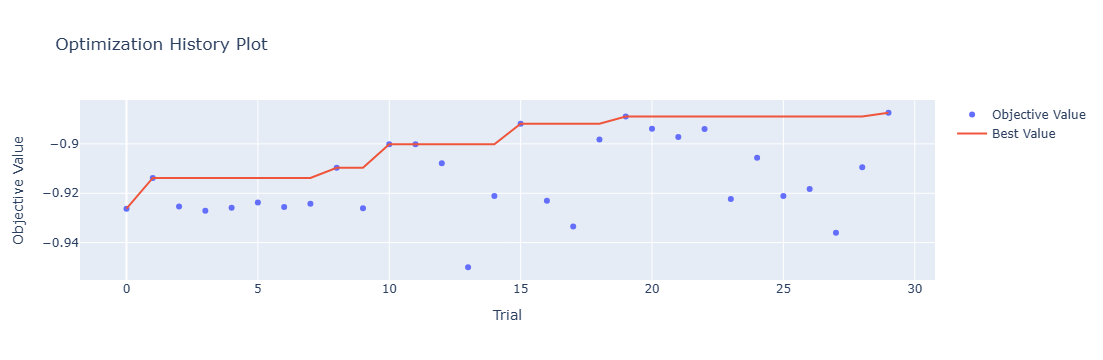

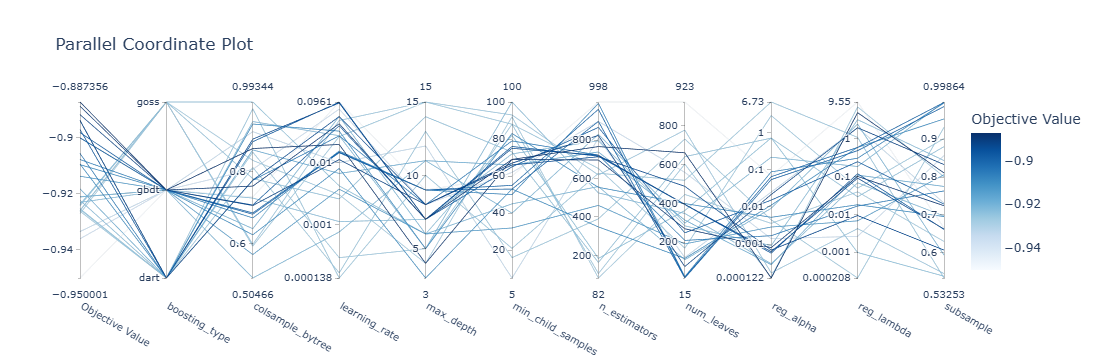

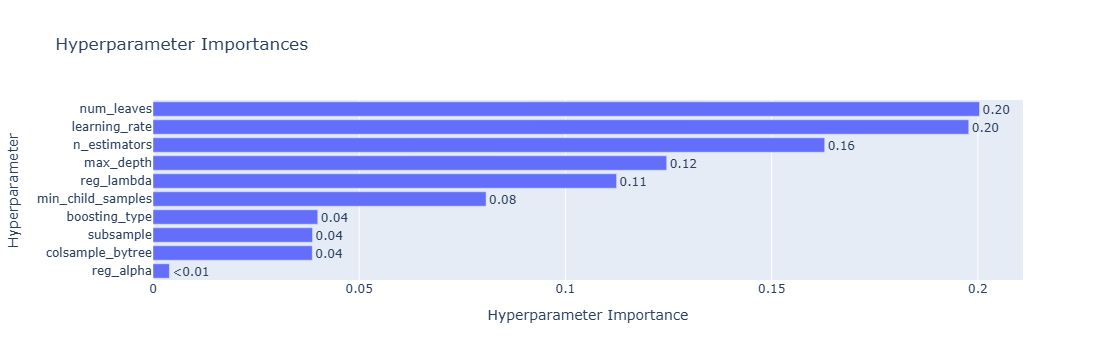

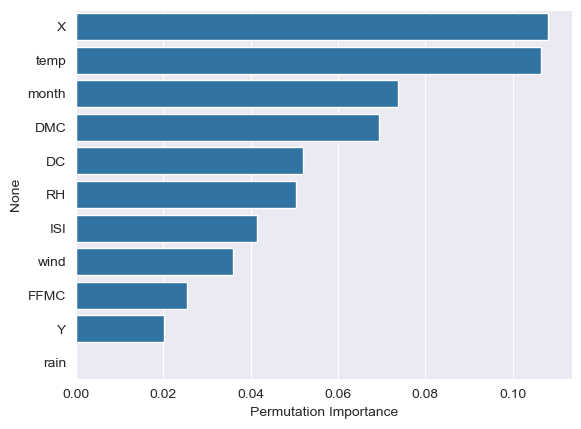

Initial_result


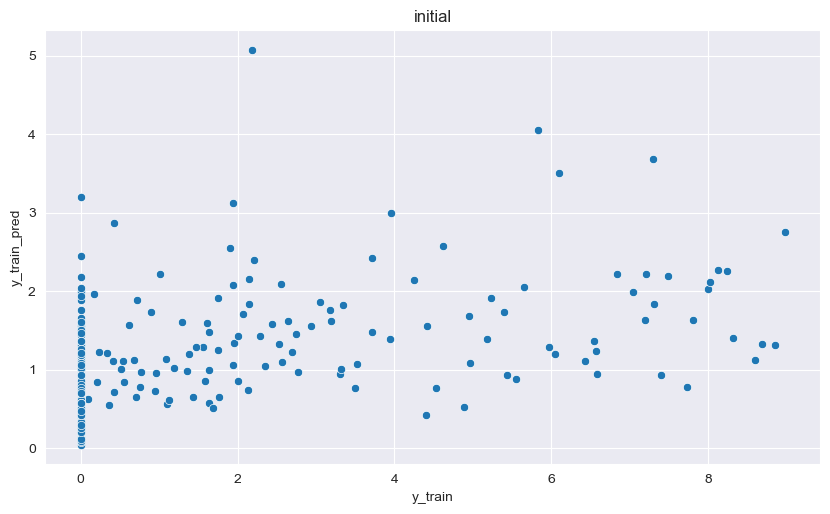

Train MAE:  11.570655655008348
Train MSE:  2452.4310785935663
Train RMSE:  49.52202619636606


In [31]:
visualization(lgbm_model, lgbm_study)
print('Initial_result')
initial_resutl(lgbm_model)

In [32]:
y_dev_pred = pt.inverse_transform(lgbm_model.predict(X_dev_scaled).reshape(-1,1)).flatten()

dev_MAE = mean_absolute_error(y_dev, y_dev_pred)
dev_MSE = mean_squared_error(y_dev, y_dev_pred)
dev_RMSE = np.sqrt(dev_MSE)

print('dev MAE: ', dev_MAE)
print('dev MSE: ', dev_MSE)
print('dev RMSE: ', dev_RMSE)

dev MAE:  19.959149390431225
dev MSE:  15494.907672806294
dev RMSE:  124.47854302170433


### Final Test Set Comparison

In [33]:
y_test_results = pd.DataFrame(columns=['Model','MAE','MSE','RMSE'])

model_dic = {
    'XGBRegressor':xgb_model,
    'SVR':svr_model,
    'RandomForestRegressor':rfr_model,
    'ElasticNet':en_model,
    'LGBMRegressor':lgbm_model
}

for i,model in enumerate(model_dic.keys()):
    y_test_pred = pt.inverse_transform(model_dic[model].predict(X_test_scaled).reshape(-1,1)).flatten()
    y_test_results.loc[i,'Model'] = model
    y_test_results.loc[i,'MAE'] = mean_absolute_error(y_test, y_test_pred)
    y_test_results.loc[i,'MSE'] = mean_squared_error(y_test, y_test_pred)
    y_test_results.loc[i,'RMSE'] = np.sqrt(mean_squared_error(y_test, y_test_pred))

y_test_results

,Model,MAE,MSE,RMSE
0,XGBRegressor,10.088807,801.33113,28.307793
1,SVR,10.23165,811.090655,28.479653
2,RandomForestRegressor,10.094655,800.552281,28.294033
3,ElasticNet,10.147436,802.778594,28.333348
4,LGBMRegressor,10.247799,802.850418,28.334615


## Summary

This notebook performs regression analysis on the 'forestfires' dataset.
It uses several models: XGBRegressor, SVR, RandomForestRegressor, ElasticNet and LGBMRegressor.
For each model, hyperparameter tuning is performed using Optuna.
The data is preprocessed using PowerTransformer and StandardScaler.
Evaluation metrics include MAE, MSE, and RMSE.  Feature importances are analyzed.
A thresholding and coefficient adjustment technique is used for improved prediction accuracy.
The notebook concludes by comparing the models' performance on a test dataset.

**Key improvements and observations:**

1. Data preprocessing: Yeo-Johnson transformation is used to handle skewed target variables.Data is standardized for model training.
2. Hyperparameter optimization: Optuna is employed for efficient hyperparameter tuning.
3. Model evaluation: Metrics include MAE, MSE, RMSE, and visualizations are employed.
4. Thresholding: A dynamic threshold is identified based on the distribution of the target variable and its predictions to improve accuracy.
5. Coefficient adjustment: A multiplication coefficient is added for further accuracy improvement.
6. Feature Importance Analysis: Permutation importance is calculated and visualized for better model understanding.

**Future work:**
* Explore other regression models.
* Investigate more sophisticated feature engineering.
* Implement more robust error analysis and handling.